In [7]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from konlpy.tag import Mecab
from sklearn.model_selection import train_test_split
from gensim.models import KeyedVectors


import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.7.0+cu128


### 데이터 확인 및 분석

#### Data Description

인공데이터입니다. 일부 이별과 관련된 질문에서 다음카페 "사랑보다 아름다운 실연( http://cafe116.daum.net/_c21_/home?grpid=1bld )"에서 자주 나오는 이야기들을 참고하여 제작하였습니다. 

가령 "이별한 지 열흘(또는 100일) 되었어요"라는 질문에 챗봇이 위로한다는 취지로 답변을 작성하였습니다.

- 챗봇 트레이닝용 문답 페어 11,876개
- 일상다반사 0, 이별(부정) 1, 사랑(긍정) 2로 레이블링

In [108]:
data = pd.read_csv("/home/summer24/DataFrom101/ddd/chatbot/data/ChatbotData.csv")


In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


In [110]:
data.label.value_counts()

label
0    5290
1    3570
2    2963
Name: count, dtype: int64

In [111]:
data.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [112]:
# 데이터 컬럼명 변경
data.rename(columns={"Q": "question", "A": "answers"}, inplace=True)
data

,question,answers,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


In [113]:
# 각 label 별 sample 확인
for label in data.label.unique():
    print(f"Label: {label}")
    print(data[data.label == label].sample(3))
    print("\n")

Label: 0
                  question               answers  label
1637             먹통이야 답답하다  대화의 눈높이가 맞는 사람 만나세요.      0
403   길거리에서 연락처 물어보면 줘도 되나          마음에 들면 줘보세요.      0
4728             커피 타기 귀찮아       커피는 셀프였으면 좋겠어요.      0


Label: 1
       question            answers  label
7332  의심이 자꾸 들어         증거를 찾아보세요.      1
5511    결국 헤어졌네  또 다른 사랑이 찾아올 거예요.      1
7302   웃는척 친구인척          척하는게 힘들죠.      1


Label: 2
                                   question             answers  label
9641                       동성친구 좋아하는 사람 없어?           생각보다 많아요.      2
9853                         사랑 받는 걸 알려준 사람          그 사람 잡으세요.      2
10960  자주 가는 카페에 잘생긴 알바생이 있는데 어떻게 고백하면 좋을까?  쪽지를 남겨서 마음을 전해보세요.      2




### 데이터 정제

In [114]:
# preprocess_sentence() 함수를 구현
# 영문자의 경우, 모두 소문자로 변환합니다.
# 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

def preprocess_sentence(sentence):
    # 영문자 소문자 변환
    sentence = sentence.lower()
    # 정규식을 활용하여 불필요한 문자 제거
    sentence = re.sub(r"[^a-z0-9가-힣\s.,!?]", "", sentence)

    return sentence

### 데이터 토큰화

token 개수 확인

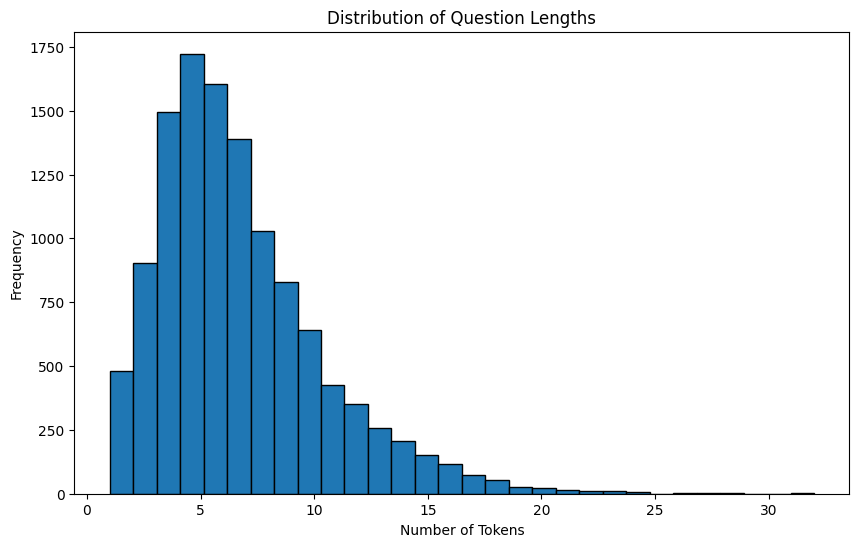

32


In [115]:
mecab = Mecab()

data["question_length"] = data["question"].apply(
    lambda x: len(mecab.morphs(preprocess_sentence(x)))
)

plt.figure(figsize=(10,6))
plt.hist(data["question_length"], bins=30, edgecolor="black")
plt.title("Distribution of Question Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

max_length = data["question_length"].max()
print(max_length)

In [34]:
def build_corpus(source_sentences, target_sentences, tokenize_fn, max_length=40):
    seen_src = set()
    seen_tgt = set()

    final_source = []
    final_target = []

    for src, tgt in zip(source_sentences, target_sentences):

        # 1. 정제
        src = preprocess_sentence(src)
        tgt = preprocess_sentence(tgt)

        # 2. 토큰화
        src_tokens = tokenize_fn(src)
        tgt_tokens = tokenize_fn(tgt)

        # 3. 길이 제한
        if len(src_tokens) > max_length or len(tgt_tokens) > max_length:
            continue

        src_tuple = tuple(src_tokens)
        tgt_tuple = tuple(tgt_tokens)

        # 4. source / target 각각 중복 검사
        if src_tuple in seen_src or tgt_tuple in seen_tgt:
            continue

        # 5. 새로운 문장만 추가
        seen_src.add(src_tuple)
        seen_tgt.add(tgt_tuple)

        final_source.append(src_tokens)
        final_target.append(tgt_tokens)

    return final_source, final_target


In [116]:
# 구현한 함수를 활용하여 questions 와 answers 를 각각 que_corpus , ans_corpus 에 토큰화하여 저장합니다.
tokenize_fn = mecab.morphs
que_corpus, ans_corpus = build_corpus(data['question'], data['answers'], tokenize_fn)

In [117]:
len(que_corpus), len(ans_corpus)

(7681, 7681)

### Augmentation

In [12]:
def lexical_sub(tokenized_sentence, model):
    # 유효한 토큰 필터링 (임베딩에 존재하는 단어만 고려)
    valid_tokens = [tok for tok in tokenized_sentence if tok in model]

    # 대체할 단어 선택 (임베딩 내 존재하는 단어 중 하나)
    if not valid_tokens:
        return tokenized_sentence  # 모든 토큰이 임베딩 내에 없으면 원래 문장 반환

    selected_tok = random.choice(valid_tokens)

    # 가장 유사한 단어 찾기
    similar_word = model.most_similar(selected_tok)[0][0]

    # 변환된 문장 생성
    new_sentence = [similar_word if tok == selected_tok else tok for tok in tokenized_sentence]

    return new_sentence


In [13]:
import gensim
model_path = "/home/summer24/DataFrom101/ddd/chatbot/embedding/ko.bin"

word2vec = gensim.models.Word2Vec.load(model_path)


In [14]:
# 1. 각각 증강된 코퍼스 생성
augmented_que_corpus_only = [lexical_sub(q, word2vec) for q in que_corpus]
augmented_ans_corpus_only = [lexical_sub(a, word2vec) for a in ans_corpus]

# 2. 주석의 로직대로 결합 (총 3배)
# 세트 1: 증강된 질문 + 원본 답변
final_que = augmented_que_corpus_only[:]
final_ans = ans_corpus[:]

# 세트 2: 원본 질문 + 증강된 답변 (누적)
final_que += que_corpus
final_ans += augmented_ans_corpus_only

# 세트 3: 원본 질문 + 원본 답변 (누적)
final_que += que_corpus
final_ans += ans_corpus

print(f"최종 데이터 개수: {len(final_que)}, {len(final_ans)}")

NameError: name 'que_corpus' is not defined

In [122]:
import pickle
import os

# 1. 저장할 경로 설정
save_path = "/home/summer24/DataFrom101/ddd/chatbot/data/augmentation_data"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. 데이터 저장 (Pickle 방식)
# final_que와 final_ans를 하나의 딕셔너리로 묶어서 저장하면 관리가 편합니다.
augmented_data = {
    "que": final_que,
    "ans": final_ans
}

file_name = os.path.join(save_path, "augmented_chatbot_data.pkl")

with open(file_name, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"✅ 저장 완료: {file_name} ({len(final_que)}개 데이터)")

# ---------------------------------------------------------
# 3. 나중에 다시 불러올 때 사용하는 코드
# ---------------------------------------------------------
"""
with open("./data/augmented_chatbot_data.pkl", "rb") as f:
    loaded_data = pickle.load(f)

final_que = loaded_data["que"]
final_ans = loaded_data["ans"]
print("데이터 로드 완료!")
"""

✅ 저장 완료: /home/summer24/DataFrom101/ddd/chatbot/data/augmentation_data/augmented_chatbot_data.pkl (23043개 데이터)


'\nwith open("./data/augmented_chatbot_data.pkl", "rb") as f:\n    loaded_data = pickle.load(f)\n\nfinal_que = loaded_data["que"]\nfinal_ans = loaded_data["ans"]\nprint("데이터 로드 완료!")\n'

### 데이터 벡터화

In [91]:
import pickle

with open("/home/summer24/DataFrom101/ddd/chatbot/data/augmentation_data/augmented_chatbot_data.pkl", "rb") as f:
    loaded_data = pickle.load(f)

final_que = loaded_data["que"]
final_ans = loaded_data["ans"]
print("데이터 로드 완료!")


데이터 로드 완료!


In [92]:
MAX_LEN = 40

def pad_sequences_custom(sequences, max_len=40, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

In [93]:
import gensim
model_path = "/home/summer24/DataFrom101/ddd/chatbot/embedding/ko.bin"

word2vec = gensim.models.Word2Vec.load(model_path)

In [94]:
from collections import Counter
import numpy as np

# 1. 사전(Vocab) 만들기
def build_vocab_from_list(que_list, ans_list, max_size=15000):
    all_tokens = []
    # 이미 리스트 형태이므로 별도의 mecab 없이 바로 합칩니다.
    for tokens in (que_list + ans_list):
        all_tokens.extend(tokens)
    
    counts = Counter(all_tokens)
    common_words = counts.most_common(max_size)
    
    # 특수 토큰 인덱스 고정
    word_to_index = {'<pad>': 0, '<unk>': 1, '<start>': 2, '<end>': 3}
    for word, _ in common_words:
        if word not in word_to_index:
            word_to_index[word] = len(word_to_index)
            
    index_to_word = {idx: word for word, idx in word_to_index.items()}
    return word_to_index, index_to_word

# 2. 사전 구축
word_to_index, index_to_word = build_vocab_from_list(final_que, final_ans)

# 3. 인덱싱 함수 (리스트 전용)
def tokenize_to_index_list(corpus, word_dict, is_ans=False):
    indexed_corpus = []
    for tokens in corpus:
        # 이미 리스트이므로 바로 인덱스로 변환
        indices = [word_dict.get(token, 1) for token in tokens]
        
        # 답변(ans)인 경우 앞뒤에 start(2), end(3) 추가
        if is_ans:
            indices = [2] + indices + [3]
            
        indexed_corpus.append(indices)
    return indexed_corpus

# 실행
indexed_que = tokenize_to_index_list(final_que, word_to_index, is_ans=False)
indexed_ans = tokenize_to_index_list(final_ans, word_to_index, is_ans=True)

# 4. 패딩 (기존 함수 사용)
que_ndarray = pad_sequences_custom(indexed_que, max_len=40, pad_value=0)
ans_ndarray = pad_sequences_custom(indexed_ans, max_len=40, pad_value=0)

# 5. 최종 검증 (이제 1이 아니라 실제 숫자가 나와야 합니다)
print("--- 검증 결과 ---")
print("질문[0] 인덱스:", indexed_que[0])
print("답변[0] 인덱스:", indexed_ans[0])

# 숫자를 다시 단어로 복원 테스트
sample_idx = indexed_ans[0]
sample_decoded = [index_to_word.get(i, '<unk>') for i in sample_idx]
print("복원된 문장:", " ".join(sample_decoded))

--- 검증 결과 ---
질문[0] 인덱스: [2222, 216, 2785, 689]
답변[0] 인덱스: [2, 284, 9, 146, 9, 43, 4, 3]
복원된 문장: <start> 하루 가 또 가 네요 . <end>


In [97]:
VOCAB_SIZE = len(word_to_index)
print(VOCAB_SIZE)

7224


### 데이터셋 및 데이터 로더 구성

In [98]:
# 1. 데이터 분리
# random_state를 고정해야 나중에 다시 실행해도 똑같이 나뉩니다.
que_train, que_val, ans_train, ans_val = train_test_split(
    que_ndarray, 
    ans_ndarray, 
    test_size=0.2, 
    random_state=42
)

# 2. 결과 확인
print("=== 데이터 분리 완료 ===")
print(f"학습용 질문: {que_train.shape}  |  학습용 답변: {ans_train.shape}")
print(f"검증용 질문: {que_val.shape}   |  검증용 답변: {ans_val.shape}")


=== 데이터 분리 완료 ===
학습용 질문: torch.Size([18434, 40])  |  학습용 답변: torch.Size([18434, 40])
검증용 질문: torch.Size([4609, 40])   |  검증용 답변: torch.Size([4609, 40])


In [99]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataset = TensorDataset(que_train, ans_train)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(que_val, ans_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)


### 모델 정의

In [100]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns



class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns


Transformer

In [101]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns


### model instance 생성

In [102]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
model = Transformer(
    n_layers=4,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

model = model.to(device)

d_model = 512

In [103]:
model

Transformer(
  (enc_emb): Embedding(7224, 512)
  (dec_emb): Embedding(7224, 512)
  (do): Dropout(p=0.3, inplace=False)
  (encoder): Encoder(
    (enc_layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (enc_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=True)
          (W_k): Linear(in_features=512, out_features=512, bias=True)
          (W_v): Linear(in_features=512, out_features=512, bias=True)
          (linear): Linear(in_features=512, out_features=512, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (do): Dropout(p=0.3, inplace=False)
      )
    )
    (do): Dropout(p=0.3, inplace=False)
  )

In [105]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60): # 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60): # 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()


### Train / Val step 정의

In [107]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu

def train_step(src, tgt, model, optimizer):
    model.train()
    optimizer.zero_grad()

    # 1. 텐서들을 먼저 Device로 보냅니다.
    src = src.to(device)
    tgt = tgt.to(device)

    # 2. 전송된 tgt에서 입력과 정답을 분리 (이러면 자동으로 같은 device 유지)
    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    # 3. 마스크 생성 (함수 내부에서 src.device를 참조하도록 설계되어야 함)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    # 만약 generate_masks가 내부에서 .to(device)를 안 해준다면 수동으로 다시 보냄
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # 4. 중요: loss 계산 시 gold와 predictions가 같은 장치에 있는지 확인
    loss = loss_function(gold, predictions)

    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

def evaluate(model, val_loader, loss_function, device, epoch, word2idx, idx2word):
    model.eval()
    total_loss = 0
    references = []
    hypotheses = []
    
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    rouge_scores = {'rouge1': 0, 'rougeL': 0}
    
    max_len = 50 
    start_idx = word2idx['<start>']
    end_idx = word2idx['<end>']
    pad_idx = word2idx['<pad>']
    
    # 패널티 강도 (1.0보다 크면 확률을 낮춤, 보통 1.2~1.5 사용)
    penalty_value = 1.5 

    with torch.no_grad():
        for src, tgt in tqdm(val_loader, desc=f"Epoch {epoch} 실전 평가"):
            src, tgt = src.to(device), tgt.to(device)
            batch_size = src.size(0)
            
            tgt_in = tgt[:, :-1]
            gold = tgt[:, 1:]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
            predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
            loss = loss_function(gold, predictions)
            total_loss += loss.item()

            generated = torch.full((batch_size, 1), start_idx, dtype=torch.long).to(device)
            eosem = torch.zeros(batch_size, dtype=torch.bool).to(device)

            for _ in range(max_len):
                enc_mask, dec_enc_mask, dec_mask = generate_masks(src, generated)
                out, _, _, _ = model(src, generated, enc_mask, dec_enc_mask, dec_mask)
                
                # 마지막 타임스텝의 로짓 추출 [batch_size, vocab_size]
                logits = out[:, -1, :]
                

                next_words = logits.argmax(dim=-1)
                generated = torch.cat([generated, next_words.unsqueeze(1)], dim=1)
                
                eosem |= (next_words == end_idx)
                if eosem.all():
                    break

            # 3. 결과 정리 및 점수 계산 (배치 전체 한꺼번에 처리)
            generated = generated.cpu().numpy()
            gold_np = gold.cpu().numpy()

            for i in range(batch_size):
                # 특수 토큰 제외하고 인덱스를 리스트로 변환
                ref = [str(idx) for idx in gold_np[i] if idx not in [pad_idx, start_idx, end_idx]]
                hyp = [str(idx) for idx in generated[i] if idx not in [pad_idx, start_idx, end_idx]]
                
                references.append([ref])
                hypotheses.append(hyp)
                
                # ROUGE 계산을 위한 문자열 변환
                ref_str = " ".join(ref)
                hyp_str = " ".join(hyp)
                if ref_str.strip() == "": continue # 빈 문장 방지
                
                score = scorer.score(ref_str, hyp_str)
                rouge_scores['rouge1'] += score['rouge1'].fmeasure
                rouge_scores['rougeL'] += score['rougeL'].fmeasure

    # 최종 점수 계산
    avg_loss = total_loss / len(val_loader)
    bleu_score = corpus_bleu(references, hypotheses) * 100
    avg_rouge = {k: v / len(references) * 100 for k, v in rouge_scores.items()}
    
    return avg_loss, bleu_score, avg_rouge

In [110]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu

# 1. 경로 및 하이퍼파라미터 설정
save_dir = "/home/summer24/DataFrom101/ddd/chatbot/checkpoint/try4"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

log_file_path = os.path.join(save_dir, "training_log.txt")
best_loss = float('inf')        # 전체 최고 성능 기록용
interval_best_loss = float('inf') # 5에포크 구간 내 최고 성능 기록용
EPOCHS = 300
patience = 15
counter = 0

# Optimizer 및 스케줄러 설정
learning_rate = LearningRateScheduler(d_model)
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=learning_rate(1), 
                             betas=(0.9, 0.98), 
                             eps=1e-9)

# 2. 학습 및 평가 루프
for epoch in range(1, EPOCHS + 1):
    print(f"\n--- Epoch {epoch} ---")
    
    # [Train 단계]
    model.train()
    total_train_loss = 0
    for src, tgt in tqdm(train_dataloader, desc="Training"):
        loss, _, _, _ = train_step(src, tgt, model, optimizer)
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_dataloader)

    # [Validation 단계]
    # word_to_index, index_to_word
    # evaluate 함수는 이전에 작성한 Batch Greedy Search 버전을 사용합니다.
    avg_val_loss, bleu, rouge = evaluate(model, val_dataloader, loss_function, device, epoch, word_to_index, index_to_word)

    # 결과 문자열 출력
    result_line = (f"Epoch [{epoch}/{EPOCHS}] "
                   f"Train Loss: {avg_train_loss:.4f} | "
                   f"Val Loss: {avg_val_loss:.4f} | "
                   f"BLEU: {bleu:.2f} | "
                   f"R1: {rouge['rouge1']:.2f} | "
                   f"RL: {rouge['rougeL']:.2f}")
    print(result_line)

    # 로그 저장
    with open(log_file_path, "a", encoding="utf-8") as f:
        f.write(result_line + "\n")

    # --- 3. 5에포크 단위 구간 Best 모델 저장 로직 ---
    if avg_val_loss < interval_best_loss:
        interval_best_loss = avg_val_loss
        
        # 구간 계산 (예: 1-5, 6-10...)
        interval_start = ((epoch - 1) // 5) * 5 + 1
        interval_end = interval_start + 4
        
        model_filename = (f"Interval_{interval_start:03d}-{interval_end:03d}_"
                          f"EP{epoch:03d}_Loss{avg_val_loss:.4f}_"
                          f"B{bleu:.2f}_R1{rouge['rouge1']:.2f}.pth")
        save_path = os.path.join(save_dir, model_filename)
        
        # 해당 구간의 이전 파일 삭제 (폴더 정리)
        for f_name in os.listdir(save_dir):
            if f_name.startswith(f"Interval_{interval_start:03d}-{interval_end:03d}") and f_name.endswith(".pth"):
                os.remove(os.path.join(save_dir, f_name))
        
        torch.save(model.state_dict(), save_path)
        print(f"✅ 구간 Best 저장: {model_filename}")

    # 5에포크마다 구간 최저치 초기화
    if epoch % 5 == 0:
        interval_best_loss = float('inf')
        print(f"🔄 에포크 {epoch} 종료: 다음 5에포크 구간을 위해 기준을 초기화합니다.")

    # --- 4. 전체 Best 기준 Early Stopping 체크 ---
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        counter = 0 
        # (전체 통합 Best 모델을 따로 관리하고 싶다면 여기에 추가 저장 로직을 넣을 수 있습니다)
    else:
        counter += 1
        print(f"⚠ 성능 개선 없음 (Early Stopping Counter: {counter}/{patience})")

    if counter >= patience:
        print(f"\n🛑 조기 종료! 최적의 모델들은 {save_dir}에 보관되어 있습니다.")
        break


--- Epoch 1 ---


Epoch 1 실전 평가: 100%|██████████| 37/37 [00:28<00:00,  1.32it/s]


Epoch [1/300] Train Loss: 138.5845 | Val Loss: 113.5515 | BLEU: 0.94 | R1: 9.37 | RL: 8.86
✅ 구간 Best 저장: Interval_001-005_EP001_Loss113.5515_B0.94_R19.37.pth

--- Epoch 2 ---


Epoch 2 실전 평가: 100%|██████████| 37/37 [00:28<00:00,  1.31it/s]


Epoch [2/300] Train Loss: 136.2969 | Val Loss: 110.1281 | BLEU: 0.81 | R1: 9.38 | RL: 8.93
✅ 구간 Best 저장: Interval_001-005_EP002_Loss110.1281_B0.81_R19.38.pth

--- Epoch 3 ---


...

Epoch [265/300] Train Loss: 19.4884 | Val Loss: 33.3009 | BLEU: 7.07 | R1: 22.65 | RL: 22.12
🔄 에포크 265 종료: 다음 5에포크 구간을 위해 기준을 초기화합니다.
⚠ 성능 개선 없음 (Early Stopping Counter: 13/15)

--- Epoch 266 ---


Epoch 266 실전 평가: 100%|██████████| 37/37 [00:28<00:00,  1.29it/s]


Epoch [266/300] Train Loss: 19.5865 | Val Loss: 33.7815 | BLEU: 7.03 | R1: 22.79 | RL: 22.33
✅ 구간 Best 저장: Interval_266-270_EP266_Loss33.7815_B7.03_R122.79.pth
⚠ 성능 개선 없음 (Early Stopping Counter: 14/15)

--- Epoch 267 ---


Epoch 267 실전 평가: 100%|██████████| 37/37 [00:28<00:00,  1.31it/s]


Epoch [267/300] Train Loss: 19.5322 | Val Loss: 32.6960 | BLEU: 7.09 | R1: 22.69 | RL: 22.23
✅ 구간 Best 저장: Interval_266-270_EP267_Loss32.6960_B7.09_R122.69.pth
⚠ 성능 개선 없음 (Early Stopping Counter: 15/15)

🛑 조기 종료! 최적의 모델들은 /home/summer24/DataFrom101/ddd/chatbot/checkpoint/try4에 보관되어 있습니다.


In [50]:
import torch
from konlpy.tag import Mecab

def greedy_decode(model, sentence, word2idx, idx2word, device, max_len=40):
    model.eval()
    mecab = Mecab()
    
    # 1. 입력 문장 토큰화 및 텐서 변환
    tokens = mecab.morphs(sentence)
    src_indices = [word2idx.get(token, word2idx['<unk>']) for token in tokens]
    src_indices = [word2idx['<start>']] + src_indices + [word2idx['<end>']]
    src_tensor = torch.LongTensor(src_indices).unsqueeze(0).to(device)
    
    # 2. Decoder 입력 초기화 (<start> 토큰으로 시작)
    target_indices = [word2idx['<start>']]
    
    with torch.no_grad():
        for i in range(max_len):
            tgt_tensor = torch.LongTensor(target_indices).unsqueeze(0).to(device)
            
            # 마스크 생성
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            
            # 모델 추론
            predictions, _, _, _ = model(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)
            
            # 마지막 타임스텝의 결과에서 가장 확률 높은 단어 선택 (Greedy)
            prediction = predictions[:, -1, :] 
            predicted_id = torch.argmax(prediction, dim=-1).item()
            
            # <end> 토큰이 나오면 생성 중단
            if predicted_id == word2idx['<end>']:
                break
                
            target_indices.append(predicted_id)
    
    # 3. 인덱스를 다시 단어로 변환 (특수 토큰 제외)
    answer = [idx2word[idx] for idx in target_indices 
              if idx not in [word2idx['<start>'], word2idx['<end>'], word2idx['<pad>']]]
    
    return "".join(answer)

# --- 수정된 실행 루프 ---
def start_chat(model_path, model, word2idx, idx2word, device):
    # 가중치 로드
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    
    print("✨ Greedy Search 챗봇이 준비되었습니다! (종료하려면 'q'를 입력하세요)")
    print("-" * 50)
    
    while True:
        user_input = input("나: ")
        if user_input.lower() in ['q', 'quit', 'exit']:
            print("대화를 종료합니다. 👋")
            break
            
        # Greedy Search를 통한 답변 생성 (훨씬 빠릅니다)
        answer = greedy_decode(model, user_input, word2idx, idx2word, device)
        
        print(f"\n[질문]: {user_input}")
        print(f"[답변]: {answer}")
        print("-" * 50)

In [51]:
import torch

# 1. 하이퍼파라미터 설정 (학습 시와 반드시 동일해야 합니다!)
# 주의: n_layers나 d_model이 다르면 가중치 로드 시 에러가 발생합니다.
MODEL_PATH = "/home/summer24/DataFrom101/ddd/chatbot/checkpoint/try3/Interval_016-020_EP018_Loss2.8617_B64.12_R178.20.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 사전(Vocab) 크기 확인
VOCAB_SIZE = len(word2idx)
print(VOCAB_SIZE)
# 3. 챗봇 가동
if __name__ == "__main__":
    try:
        # 가중치를 로드하고 대화를 시작합니다.
        start_chat(
            model_path=MODEL_PATH,
            model=model,
            word2idx=word2idx,
            idx2word=idx2word,
            device=device
        )
    except FileNotFoundError:
        print(f"❌ 모델 파일을 찾을 수 없습니다. 경로를 확인하세요: {MODEL_PATH}")
    except RuntimeError as e:
        print(f"❌ 모델 구조 불일치 에러: n_layers 등 설정을 확인하세요.\n{e}")
    except Exception as e:
        print(f"❌ 기타 에러 발생: {e}")

30189
✨ Greedy Search 챗봇이 준비되었습니다! (종료하려면 'q'를 입력하세요)
--------------------------------------------------

[질문]: 안녕하세요
[답변]: <unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>
--------------------------------------------------

[질문]: 나 배고파
[답변]: <unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>
--------------------------------------------------

[질문]: 졸려
[답변]: <unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>
--------------------------------------------------

[질문]: 나 차일거같ㅇ아
[답변]: <unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><un

KeyboardInterrupt: Interrupted by user

In [52]:
for src, tgt in train_dataloader:
    print("소스 문장(숫자):", src[0]) # 첫 번째 배치의 첫 문장
    print("타겟 문장(숫자):", tgt[0])
    break
# 출력된 숫자 리스트에 1(unk)이 너무 많다면 데이터셋 생성 로직이 잘못된 것입니다.

소스 문장(숫자): tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
타겟 문장(숫자): tensor([2, 1, 1, 1, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


### 인퍼런스 결과

#### Epoch 78 'bleu_0.57 | R1: 9.51 | RL: 8.68'

- best_model_loss_352.8522_bleu_0.57.pth
- bleu_0.57 | R1: 9.51 | RL: 8.68

```✨ Greedy Search 챗봇이 준비되었습니다! (종료하려면 'q'를 입력하세요)
--------------------------------------------------

[질문]: 안녕하세요
[답변]: 보면좋을보세요.
--------------------------------------------------

[질문]: 나 배고파
[답변]: 더있게좋을수있을거같아요.
--------------------------------------------------

[질문]: 졸려
[답변]: 더있게<unk>는데
--------------------------------------------------

[질문]: 나 차일거같아
[답변]: 나좋아보는사람이고더좋을수도있어요.
--------------------------------------------------

[질문]: 사랑해
[답변]: 사랑은더좋은이있어요.
--------------------------------------------------

[질문]: 친구 만날까
[답변]: 더좋을보세요.
--------------------------------------------------

[질문]: 사랑이 뭘까
[답변]: 해보세요.
--------------------------------------------------

[질문]: 좋아하면 원래 더 주고 싶나?
[답변]: 하지않는다면<unk>는데
--------------------------------------------------

[질문]: 보고싶다
[답변]: 나은사람이랑결혼하지않은사람이랑결혼을수도있을수도있을수도있을수도있을거<unk>는데
--------------------------------------------------

[질문]: 결혼 어떻게 해?
[답변]: 나은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은사랑은
--------------------------------------------------

[질문]: 나 그 사람이 너무 싫어
[답변]: 보면더힘들어요.
--------------------------------------------------
대화를 종료합니다. 👋```

#### Epoch 74 'BLEU: 0.47 | R1: 12.35 | RL: 11.88`



`Train Loss: 398.4853 | Val Loss: 384.9698 | BLEU: 0.47 | R1: 12.35 | RL: 11.88`


```✨ Greedy Search 챗봇이 준비되었습니다! (종료하려면 'q'를 입력하세요)
--------------------------------------------------

[질문]: 안녕하세요
[답변]: 이네요.
--------------------------------------------------

[질문]: 나 배고파
[답변]: 사랑의좋은거같아요.
--------------------------------------------------

[질문]: 졸려
[답변]: 사랑의좋은게좋을거같아요.
--------------------------------------------------

[질문]: 나 차일거같아
[답변]: 나좋아보는사람이고싶은사람이고싶은사람이고싶다고못이고싶은사람이고있어요.
--------------------------------------------------

[질문]: 사랑해
[답변]: 사랑의좋은거같아요.
--------------------------------------------------

[질문]: 친구 만날까?
[답변]: 사람이있는게아니라면<unk>.
--------------------------------------------------

[질문]: 사랑이 뭘까
[답변]: 말해가있을수있을거같아요.
--------------------------------------------------

[질문]: 좋아하면 원래 더 주고 싶나?
[답변]: 사랑은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람은사람마다.
--------------------------------------------------

[질문]: 보고싶다
[답변]: 이되하면좋을것같아요.
--------------------------------------------------

[질문]: 결혼 어떻게 해?
[답변]: 사람도하는거같아요.
--------------------------------------------------

[질문]: 나 그 사람이 너무 싫어
[답변]: 사랑의좋을수도있을거같아요.
--------------------------------------------------

[질문]: 1
[답변]: 사랑의좋은게좋을거같아요.
--------------------------------------------------
대화를 종료합니다. 👋```

#### Epoch 33 BLEU: 0.90 | R1: 13.73 | RL: 12.34

Train Loss: 938.4619 | Val Loss: 805.9481 | BLEU: 0.90 | R1: 13.73 | RL: 12.34

```✨ Greedy Search 챗봇이 준비되었습니다! (종료하려면 'q'를 입력하세요)
--------------------------------------------------

[질문]: 안녕하세요
[답변]: 좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은
--------------------------------------------------

[질문]: 나 배고파
[답변]: 좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은
--------------------------------------------------

[질문]: 졸려
[답변]: 좋은마음이있을하는게좋을거<unk>.
--------------------------------------------------

[질문]: 나 차일거같아
[답변]: 사랑이있을거<unk>.
--------------------------------------------------

[질문]: 사랑해
[답변]: 사랑이있을하는거같아요.
--------------------------------------------------

[질문]: 친구 만날까
[답변]: 좋은좋은좋은좋은좋을수있을수있을수있을수있을수있을수있을수있을수있을수있을수있을수있을수있을수있을하
--------------------------------------------------

[질문]: 사랑이 뭘까
[답변]: 사랑이있을하는것같아요.
--------------------------------------------------

[질문]: 좋아하면 원래 더 주고 싶나?
[답변]: 사랑을하는것같아요.
--------------------------------------------------

[질문]: 보고싶다
[답변]: 좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋은좋겠네요.
--------------------------------------------------

[질문]: 결혼 어떻게 해?
[답변]: 사랑이있을하는사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑사람이랑하죠
--------------------------------------------------

[질문]: 나 그 사람이 너무 싫어
[답변]: 사랑이있을거<unk>.
--------------------------------------------------
대화를 종료합니다. 👋```

회고

- chatbot을 만들면서 문맥을 잘 이해하는 챗봇을 만드는게 어렵다고 생각이 드렀다

- 문법에 대해 잘 배우지 못하는 게 이 모델의 문제점인것 같다는 생각도 들었다. 